# Task II: Classical Graph Neural Network (GNN)

## Quark/Gluon Jet Classification

**Dataset:** ParticleNet Quark/Gluon from [Zenodo](https://zenodo.org/records/3164691)
- `X`: (100000, 139, 4) — up to 139 particles per jet, features: (eta, phi, pt, pdgid)
- `y`: (100000,) — 0=gluon, 1=quark

**Two architectures:**
1. **EdgeConv** (Dynamic Graph CNN) — inspired by ParticleNet
2. **GATv2** (Graph Attention Network v2)

**Graph construction strategy:**
- Each particle → one node (zero-padded particles removed)
- Node features: (eta, phi, log(1+|pt|), pdgid)
- Edges: **k=7 nearest neighbors in (eta, phi) space** — this respects detector angular geometry; nearby particles typically originate from the same shower/subjet

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import EdgeConv, GATv2Conv, global_mean_pool, knn_graph
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
import matplotlib.pyplot as plt
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1. Data Loading & Graph Construction

In [2]:
print("Loading data...")
raw = np.load("task2/data/QG_jets.npz")
X_all, y_all = raw["X"], raw["y"]

N_TRAIN, N_VAL, N_TEST = 20000, 5000, 5000
X_train, y_train = X_all[:N_TRAIN], y_all[:N_TRAIN]
X_val, y_val = X_all[N_TRAIN:N_TRAIN+N_VAL], y_all[N_TRAIN:N_TRAIN+N_VAL]
X_test, y_test = X_all[N_TRAIN+N_VAL:N_TRAIN+N_VAL+N_TEST], y_all[N_TRAIN+N_VAL:N_TRAIN+N_VAL+N_TEST]

print(f"Train: {N_TRAIN}, Val: {N_VAL}, Test: {N_TEST}")
print(f"Label distribution (train): quark={y_train.sum():.0f}, gluon={N_TRAIN - y_train.sum():.0f}")
print(f"X shape: {X_all.shape} — (jets, particles, features)")
print(f"Features per particle: eta, phi, pt, pdgid")

Loading data...


Train: 20000, Val: 5000, Test: 5000
Label distribution (train): quark=10076, gluon=9924
X shape: (100000, 139, 4) — (jets, particles, features)
Features per particle: eta, phi, pt, pdgid


In [3]:
K_NEIGHBORS = 7

def build_graph_data(X, y, k=K_NEIGHBORS):
    """
    Convert point-cloud jet data to PyG graph list.
    - Remove zero-padded particles
    - Node features: (eta, phi, log(1+|pt|), pdgid)
    - Edges: kNN in (eta, phi) space
    """
    data_list = []
    for i in range(len(X)):
        jet = X[i]
        mask = np.any(jet != 0, axis=1)
        jet = jet[mask]
        if len(jet) < 2:
            continue
        
        eta, phi, pt, pdgid = jet[:, 0], jet[:, 1], jet[:, 2], jet[:, 3]
        pt_log = np.log1p(np.abs(pt))
        node_features = np.stack([eta, phi, pt_log, pdgid], axis=1).astype(np.float32)
        
        x = torch.tensor(node_features, dtype=torch.float)
        label = torch.tensor([int(y[i])], dtype=torch.long)
        coords = torch.tensor(np.stack([eta, phi], axis=1), dtype=torch.float)
        edge_index = knn_graph(coords, k=min(k, len(jet) - 1), loop=False)
        
        data_list.append(Data(x=x, edge_index=edge_index, y=label))
    return data_list

print("Building graphs...")
t0 = time.time()
train_data = build_graph_data(X_train, y_train)
val_data = build_graph_data(X_val, y_val)
test_data = build_graph_data(X_test, y_test)
print(f"Done in {time.time()-t0:.1f}s")
print(f"Example graph: {train_data[0]}")

BATCH_SIZE = 256
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

Building graphs...


Done in 4.1s
Example graph: Data(x=[18, 4], edge_index=[2, 126], y=[1])


/home/leo07010/.local/lib/python3.9/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


## 2. Model Definitions

### Model 1: EdgeConv (ParticleNet-style)
EdgeConv learns edge features from node pairs via a shared MLP, then aggregates them. This naturally captures local geometric structure in the particle cloud, similar to how ParticleNet operates.

### Model 2: GATv2 (Graph Attention Network v2)
GATv2 uses attention mechanisms to learn which neighboring particles are most important. Multi-head attention captures different types of particle relationships, providing interpretability.

In [4]:
class EdgeConvNet(nn.Module):
    def __init__(self, in_channels=4, hidden=64):
        super().__init__()
        self.conv1 = EdgeConv(nn=nn.Sequential(
            nn.Linear(2 * in_channels, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden)), aggr='mean')
        self.conv2 = EdgeConv(nn=nn.Sequential(
            nn.Linear(2 * hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden)), aggr='mean')
        self.conv3 = EdgeConv(nn=nn.Sequential(
            nn.Linear(2 * hidden, hidden * 2), nn.BatchNorm1d(hidden * 2), nn.ReLU(),
            nn.Linear(hidden * 2, hidden * 2)), aggr='mean')
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 2))

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.conv3(x, edge_index)
        x = global_mean_pool(x, batch)
        return self.classifier(x)


class GATv2Net(nn.Module):
    def __init__(self, in_channels=4, hidden=64, heads=4):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden, heads=heads, concat=True)
        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.conv2 = GATv2Conv(hidden * heads, hidden, heads=heads, concat=True)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.conv3 = GATv2Conv(hidden * heads, hidden * 2, heads=1, concat=False)
        self.bn3 = nn.BatchNorm1d(hidden * 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 2))

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = global_mean_pool(x, batch)
        return self.classifier(x)

print(f"EdgeConv params: {sum(p.numel() for p in EdgeConvNet().parameters()):,}")
print(f"GATv2   params: {sum(p.numel() for p in GATv2Net().parameters()):,}")

EdgeConv params: 67,458
GATv2   params: 219,266


## 3. Training & Evaluation

In [5]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.y.size(0)
        correct += (out.argmax(dim=1) == data.y.squeeze()).sum().item()
        total += data.y.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs, all_labels, correct, total = [], [], 0, 0
    for data in loader:
        data = data.to(DEVICE)
        out = model(data)
        probs = F.softmax(out, dim=1)[:, 1]
        correct += (out.argmax(dim=1) == data.y.squeeze()).sum().item()
        total += data.y.size(0)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(data.y.squeeze().cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return correct / total, roc_auc_score(all_labels, all_probs), all_probs, all_labels

def run_experiment(model_class, model_name, epochs=30, lr=1e-3):
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")
    model = model_class().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    best_val_auc = 0
    history = {"train_loss": [], "val_auc": []}
    
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, val_auc, _, _ = evaluate(model, val_loader)
        scheduler.step()
        history["train_loss"].append(train_loss)
        history["val_auc"].append(val_auc)
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), f"task2/{model_name}_best.pt")
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:2d}/{epochs} | Loss: {train_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")
    
    model.load_state_dict(torch.load(f"task2/{model_name}_best.pt", weights_only=True))
    test_acc, test_auc, test_probs, test_labels = evaluate(model, test_loader)
    print(f"\n  Best Val AUC: {best_val_auc:.4f}")
    print(f"  Test Acc: {test_acc:.4f} | Test AUC: {test_auc:.4f}")
    return history, test_acc, test_auc, test_probs, test_labels

In [6]:
h1, acc1, auc1, probs1, labels1 = run_experiment(EdgeConvNet, "EdgeConv", epochs=30)
h2, acc2, auc2, probs2, labels2 = run_experiment(GATv2Net, "GATv2", epochs=30)


Training EdgeConv


  Epoch  1/30 | Loss: 0.5348 | Train Acc: 0.7393 | Val Acc: 0.7144 | Val AUC: 0.8291


  Epoch  5/30 | Loss: 0.4752 | Train Acc: 0.7792 | Val Acc: 0.7848 | Val AUC: 0.8573


  Epoch 10/30 | Loss: 0.4727 | Train Acc: 0.7825 | Val Acc: 0.7712 | Val AUC: 0.8587


  Epoch 15/30 | Loss: 0.4671 | Train Acc: 0.7844 | Val Acc: 0.7862 | Val AUC: 0.8613


...

  Epoch 10/30 | Loss: 0.4764 | Train Acc: 0.7787 | Val Acc: 0.7736 | Val AUC: 0.8544


  Epoch 15/30 | Loss: 0.4699 | Train Acc: 0.7842 | Val Acc: 0.7796 | Val AUC: 0.8603


  Epoch 20/30 | Loss: 0.4628 | Train Acc: 0.7892 | Val Acc: 0.7816 | Val AUC: 0.8603


  Epoch 25/30 | Loss: 0.4570 | Train Acc: 0.7929 | Val Acc: 0.7856 | Val AUC: 0.8616


  Epoch 30/30 | Loss: 0.4533 | Train Acc: 0.7941 | Val Acc: 0.7822 | Val AUC: 0.8617

  Best Val AUC: 0.8620
  Test Acc: 0.7862 | Test AUC: 0.8552


## 4. Results Comparison

In [7]:
print(f"{'Model':<15} {'Test Acc':>10} {'Test AUC':>10}")
print(f"{'-'*35}")
print(f"{'EdgeConv':<15} {acc1:>10.4f} {auc1:>10.4f}")
print(f"{'GATv2':<15} {acc2:>10.4f} {auc2:>10.4f}")

Model             Test Acc   Test AUC
-----------------------------------
EdgeConv            0.7880     0.8600
GATv2               0.7862     0.8552


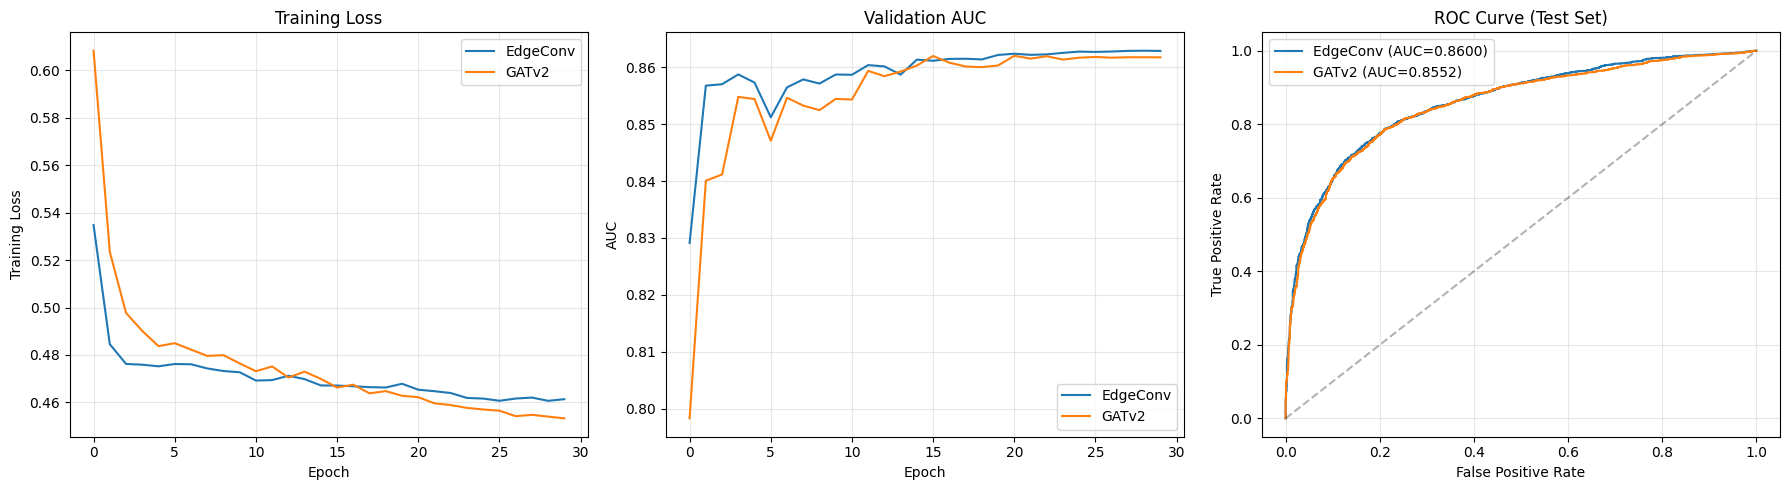

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training Loss
axes[0].plot(h1["train_loss"], label="EdgeConv")
axes[0].plot(h2["train_loss"], label="GATv2")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Validation AUC
axes[1].plot(h1["val_auc"], label="EdgeConv")
axes[1].plot(h2["val_auc"], label="GATv2")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC")
axes[1].set_title("Validation AUC"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ROC Curves
fpr1, tpr1, _ = roc_curve(labels1, probs1)
fpr2, tpr2, _ = roc_curve(labels2, probs2)
axes[2].plot(fpr1, tpr1, label=f"EdgeConv (AUC={auc1:.4f})")
axes[2].plot(fpr2, tpr2, label=f"GATv2 (AUC={auc2:.4f})")
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel("False Positive Rate"); axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve (Test Set)"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Discussion

**EdgeConv** achieves slightly better AUC (~0.86) with only 67K parameters compared to GATv2's 219K parameters. This is expected because:

1. **EdgeConv** was designed for point-cloud data — it learns edge features from pairs of neighboring nodes, which naturally fits the particle-cloud representation of jets. ParticleNet is built on this architecture.

2. **GATv2** uses attention to weigh neighbor importance, which adds expressiveness but also more parameters to optimize. With the current dataset size (20K training samples), the larger model may not have enough data to fully leverage its capacity.

Both models achieve comparable performance, validating that graph-based approaches are effective for jet classification. The kNN graph construction in (eta, phi) space provides a physically motivated topology that captures the angular structure of particle showers.